In [1]:
import pandas as pd

# Загружаем данные
file_path = "experiment_lesson_4.csv"
df = pd.read_csv(file_path)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

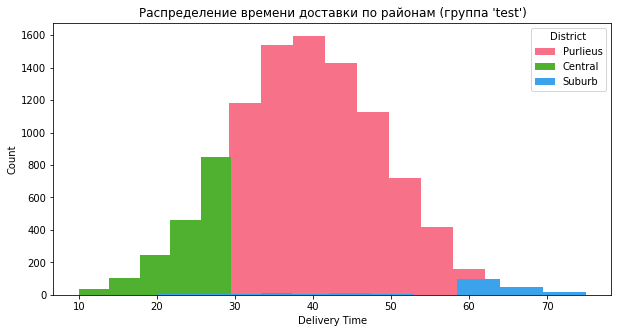

In [11]:
# Фильтруем данные (только experiment_group == "test")
df_filtered = df[df["experiment_group"] == "test"]

# Уникальные районы и цвета для них
districts = df_filtered["district"].unique()
colors = sns.color_palette("husl", len(districts))  # Генерация разных цветов

# Строим гистограмму с разделением по районам
plt.figure(figsize=(10, 5))

for district, color in zip(districts, colors):
    subset = df_filtered[df_filtered["district"] == district]
    plt.hist(subset["delivery_time"], color=color, label=district)

plt.xlabel("Delivery Time")
plt.ylabel("Count")
plt.title("Распределение времени доставки по районам (группа 'test')")
plt.legend(title="District")
plt.show()

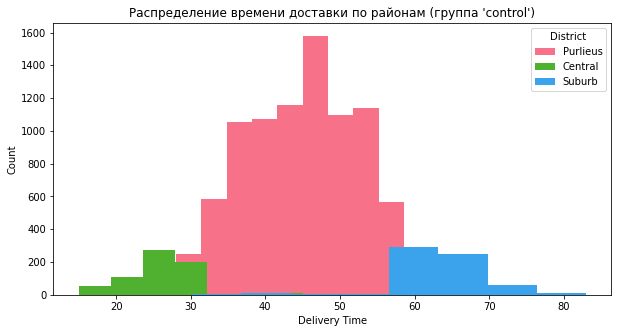

In [12]:
# Фильтруем данные (только experiment_group == "control")
df_filtered2 = df[df["experiment_group"] == "control"]

# Уникальные районы и цвета для них
districts = df_filtered["district"].unique()
colors = sns.color_palette("husl", len(districts))  # Генерация разных цветов

# Строим гистограмму с разделением по районам
plt.figure(figsize=(10, 5))

for district, color in zip(districts, colors):
    subset = df_filtered2[df_filtered2["district"] == district]
    plt.hist(subset["delivery_time"], color=color, label=district)

plt.xlabel("Delivery Time")
plt.ylabel("Count")
plt.title("Распределение времени доставки по районам (группа 'control')")
plt.legend(title="District")
plt.show()

In [13]:
df_filtered.count()

order_id            10104
delivery_time       10104
district            10104
experiment_group    10104
dtype: int64

In [14]:
df_filtered2.count()

order_id            10092
delivery_time       10092
district            10092
experiment_group    10092
dtype: int64

In [15]:
import scipy

In [18]:
scipy.stats.normaltest(df_filtered['delivery_time'])

NormaltestResult(statistic=7.024157092641915, pvalue=0.02983483685333173)

In [19]:
scipy.stats.normaltest(df_filtered2['delivery_time'])

NormaltestResult(statistic=0.25349755437872584, pvalue=0.8809549607809654)

In [20]:
std = df_filtered['delivery_time'].std()
print(std)

9.883308351129061


In [21]:
std2 = df_filtered2['delivery_time'].std()
print(std2)

9.990016960246372


In [22]:
scipy.stats.ttest_ind(df_filtered['delivery_time'], df_filtered2['delivery_time'])

Ttest_indResult(statistic=-43.03582663183714, pvalue=0.0)

In [34]:
df_filtered['delivery_time'].mean()

39.04681314330958

In [35]:
df_filtered2['delivery_time'].mean()

45.065101070154576

In [36]:
1 - 39.04681314330958/45.065101070154576

0.1335465312166081